In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch

In [14]:
rsm=fits.open('F:/HA/13386/072800/B060_redata/Ha_13386_2023-07-31T08_08_07.117_level1+.fits')
ha=rsm[0].data[:,:]
ha2=ha.T
ha=[row[::-1] for row in ha2]
ha=np.array(ha)

In [15]:
print(ha2.shape)
print(ha.shape)

(1024, 1024)
(1024, 1024)


(1024, 1024)


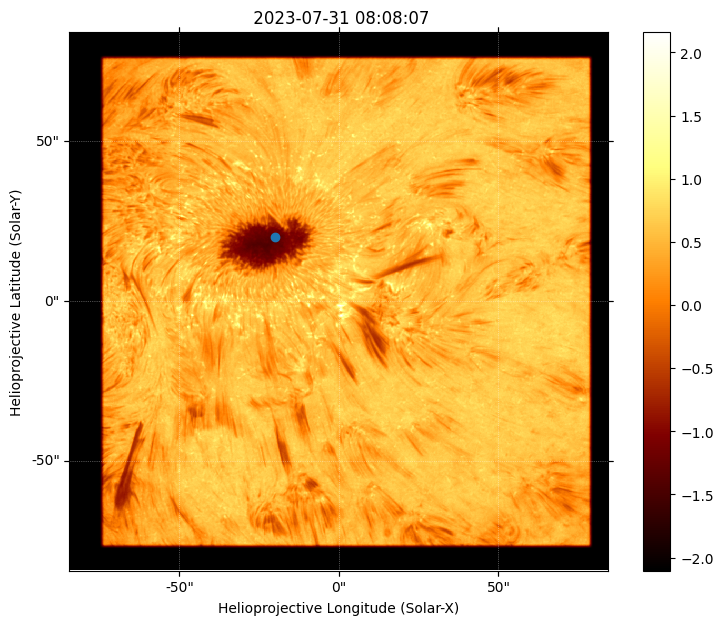

In [21]:
rsm=fits.open('F:/HA/13386/072800/B060_redata/Ha_13386_2023-07-31T08_08_07.117_level1+.fits')
ha=rsm[0].data[:,:]
ha2=ha.T
ha=[row[::-1] for row in ha2]
ha=np.array(ha)
ha=ha[::-1]
mean_ha=np.mean(ha)
std_ha=np.std(ha)
ha=(ha-mean_ha)/std_ha
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2023-07-31 08:08:07.117', observer = 'earth', \
                     frame = frames.Helioprojective)
headerha=sunpy.map.make_fitswcs_header(ha,coord_HIS,
                                       scale=[0.165,0.165]*u.arcsec/u.pixel,
                                       telescope='FSO NVST',instrument='HRIS')
ha_map=sunpy.map.Map(ha,headerha)
fig=plt.figure(figsize=(9,7))
ax=fig.add_subplot(projection=ha_map)
ha_map.plot(axes=ax,cmap = 'afmhot')

#ha_map.draw_grid(color='black',axes=ax,grid_spacing=6000*u.arcsec)
print(ha.shape)
plt.colorbar()
coords = SkyCoord(Tx=-20* u.arcsec, Ty=20 * u.arcsec, frame=ha_map.coordinate_frame)
ax.plot_coord(coords,'o')

[AIA简介](https://aia.cfa.harvard.edu/)  
The Atmospheric Imaging Assembly (AIA) is a four-telescope array, operating primarily in the extreme ultraviolet (EUV), aboard NASA's Solar Dynamics Observatory (SDO) - the current flagship of the Living With a Star program. AIA is a coordinated effort led by the Lockheed Martin Solar and Astrophysics Laboratory (LMSAL) with the Smithsonian Astrophysical Observatory (SAO) as the major subcontractor, responsible for building the telescope assemblies and for assistance with calibration, data handling, and interpretation. CCD cameras for the AIA telescopes have been provided by MSSL, RAL, and E2V.

大气成像组件（AIA）是一个四望远镜阵列，主要在极紫外（EUV）中运行，搭载在美国国家航空航天局的太阳动力学天文台（SDO）上，该天文台是“与星共存”计划的当前旗舰。AIA是由洛克希德·马丁太阳能和天体物理实验室（LMSAL）领导的一项协调工作，史密森天体物理天文台（SAO）是主要分包商，负责建造望远镜组件并协助校准、数据处理和解释。AIA望远镜的CCD相机由MSSL、RAL和E2V提供。

WCS World Coordinate System

In [2]:
@u.quantity_input
def speed (length:u.m,time:u.s) -> u.m/u.s:
    return length/time
print(speed(15*u.mm,3*u.s))

0.005 m / s


In [3]:
import sunpy.time
sunpy.time.parse_time('2021/08/01')

<Time object: scale='utc' format='isot' value=2021-08-01T00:00:00.000>

In [4]:
from sunpy.time import TimeRange
time_range = TimeRange('2010/03/04 00:10', '2010/03/04 00:20')
time_range.seconds

<Quantity 600. s>

In [5]:
time_range.center

<Time object: scale='utc' format='isot' value=2010-03-04T00:15:00.000>

In [6]:
time_range.split(2)

[   <sunpy.time.timerange.TimeRange object at 0x15d295aab10>
     Start: 2010-03-04 00:10:00
     End:   2010-03-04 00:15:00
     Center:2010-03-04 00:12:30
     Duration:0.00347222222222221 days or
            0.08333333333333304 hours or
            4.999999999999982 minutes or
            299.9999999999989 seconds,
     Start: 2010-03-04 00:15:00
     End:   2010-03-04 00:20:00
     Center:2010-03-04 00:17:30
     Duration:0.00347222222222221 days or
            0.08333333333333304 hours or
            4.999999999999982 minutes or
            299.9999999999989 seconds]

In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from sunpy.coordinates import frames

In [8]:
coord = SkyCoord(70*u.deg, -30*u.deg, obstime="2017-08-01",
                 frame=frames.HeliographicStonyhurst)
coord

<SkyCoord (HeliographicStonyhurst: obstime=2017-08-01T00:00:00.000, rsun=695700.0 km): (lon, lat) in deg
    (70., -30.)>

In [9]:
coord.transform_to(frames.Helioprojective(observer="earth"))

<SkyCoord (Helioprojective: obstime=2017-08-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (Tx, Ty, distance) in (arcsec, arcsec, km)
    (769.96270814, -498.89715922, 1.51668773e+08)>

In [10]:
coord = SkyCoord([-500, 400]*u.arcsec, [100, 200]*u.arcsec, frame=frames.Helioprojective)
coord

<SkyCoord (Helioprojective: obstime=None, rsun=695700.0 km, observer=None): (Tx, Ty) in arcsec
    [(-500., 100.), ( 400., 200.)]>

In [11]:
coord[0]

<SkyCoord (Helioprojective: obstime=None, rsun=695700.0 km, observer=None): (Tx, Ty) in arcsec
    (-500., 100.)>

__<font color='#FF7F00'>4. Observer Location</font>__

可以通过输入 <font color='00FFFF'>obstime</font> 更改观测者位置

In [12]:
hpc = SkyCoord(0*u.arcsec, 0*u.arcsec, observer="earth",
                obstime="2017-07-26",
                frame=frames.Helioprojective)

hpc.transform_to(frames.Helioprojective(observer="venus",
                                         obstime="2017-07-26"))

<SkyCoord (Helioprojective: obstime=2017-07-26T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'venus'>): (Tx, Ty, distance) in (arcsec, arcsec, AU)
    (-1285.47497992, 106.20918654, 0.72405937)>

__<font color='#FF7F00'>5. Using Coordinates with Maps</font>__

利用coordinates确定坐标在图上的位置，并通过header information创建coordiante frame，利用 <font color='#00FFFF'>.coordinate_frame</font>

In [6]:
from astropy.coordinates import SkyCoord
import astropy.units as u

import sunpy.map
from sunpy.data.sample import AIA_171_IMAGE  

amap = sunpy.map.Map(AIA_171_IMAGE)  
amap.coordinate_frame  

<Helioprojective Frame (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>)>

In [8]:
coord=SkyCoord(100*u.arcsec,10*u.arcsec,frame=amap.coordinate_frame)
coord

<SkyCoord (Helioprojective: obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>): (Tx, Ty) in arcsec
    (100., 10.)>

可以利用 <font color='#00FFFF'>GenericMap.wcs.world_to_pixel</font> 将SkyCoord object转化为一个像素点

In [13]:
pixels=amap.wcs.world_to_pixel(coord)
print(pixels)

(array(551.7680511), array(515.18266871))


将这个像素点在图里画出来

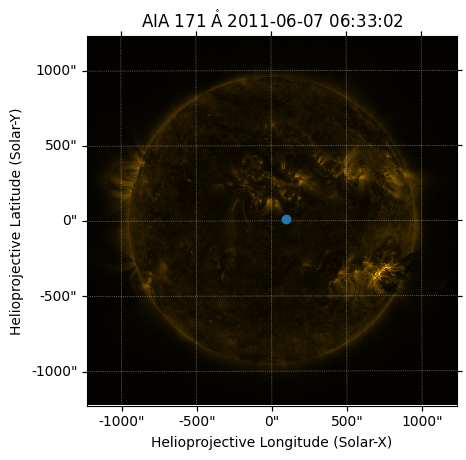

In [16]:
import matplotlib.pyplot as plt
fig=plt.figure()
ax=plt.subplot(projection=amap)
amap.plot()
ax.plot_coord(coord,'o')

__<font size=5 color='#FF0000'>五. Acquaring Data</font>__

利用<font color='#00FFFF'>Fido</font>获取数据，具体教程  
[Joint Science Operations Center(JSOC)](https://docs.sunpy.org/en/stable/tutorial/acquiring_data/jsoc.html) 以及
[Heliophysics Event Knowledgebase (HEK)](https://docs.sunpy.org/en/stable/tutorial/acquiring_data/hek.html)

In [17]:
from sunpy.net import attrs as a

ModuleNotFoundError: No module named 'requests'

In [18]:
sunpy.__version__

'5.1.0'

__<font size=5 color='#FF0000'>六. Maps</font>__  

__<font color='#FF7F00'>1. Creating Maps</font>__  
Map object包括二维数据和元数据

In [3]:
import sunpy.map
import sunpy.data.sample  

sunpy.data.sample.AIA_171_IMAGE  


WindowsPath('C:/Users/19671/AppData/Local/sunpy/sunpy/AIA20110607_063302_0171_lowres.fits')

In [5]:
my_map=sunpy.map.Map(sunpy.data.sample.AIA_171_IMAGE)

Observatory,SDO
Instrument,AIA 3
Detector,AIA
Measurement,171.0 Angstrom
Wavelength,171.0 Angstrom
Observation Date,2011-06-07 06:33:02
Exposure Time,0.234256 s
Dimension,[1024. 1024.] pix
Coordinate System,helioprojective
Scale,[2.402792 2.402792] arcsec / pix
Reference Pixel,[511.5 511.5] pix

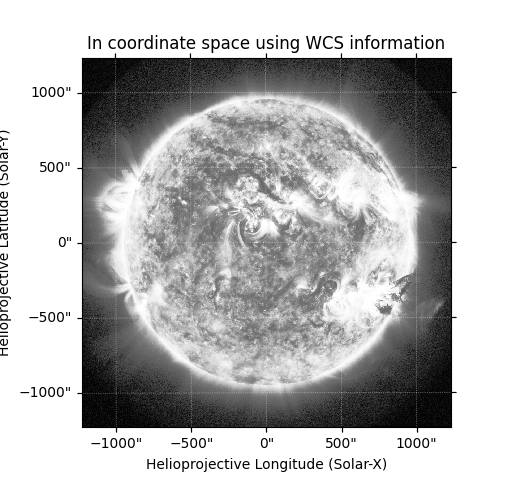
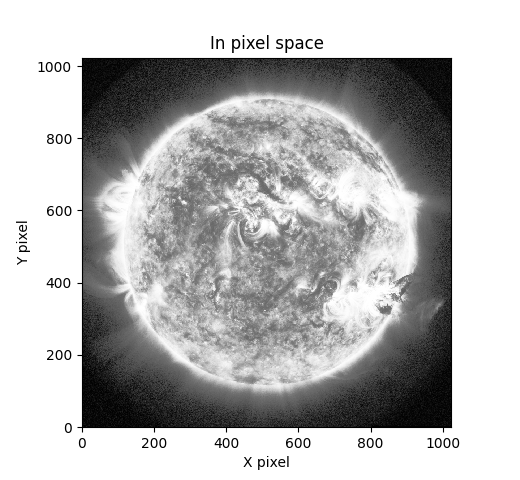
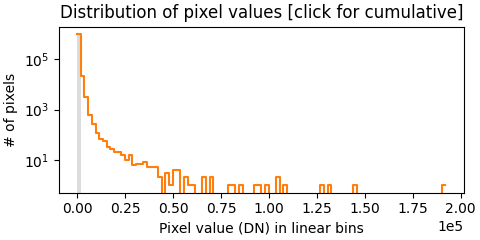
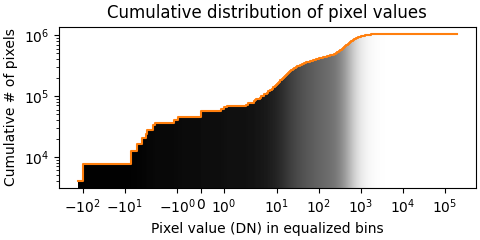

In [6]:
my_map

In [22]:
#用浏览器打开
my_map.quicklook()

__<font color='#FF7F00'>2. Inspecting Map Metadata</font>__  

利用 <font color='#00FFFF'>my_map.\<attribute-name\></font>获取相应信息  
日期，曝光时间，上面有什么这就能有什么

In [7]:
my_map.date

<Time object: scale='utc' format='isot' value=2011-06-07T06:33:02.770>

In [24]:
my_map.exposure_time

<Quantity 0.234256 s>

<font color='#00FFFF'>第一个index是y轴，第二个是x轴</font>

In [25]:
my_map.data

array([[ -95.92475  ,    7.076416 ,   -1.9656711, ..., -127.96519  ,
        -127.96519  , -127.96519  ],
       [ -96.97533  ,   -5.1167884,    0.       , ...,  -98.924576 ,
        -104.04137  , -127.919716 ],
       [ -93.99607  ,    1.0189276,   -4.0757103, ...,   -5.094638 ,
         -37.95505  , -127.87541  ],
       ...,
       [-128.01454  , -128.01454  , -128.01454  , ..., -128.01454  ,
        -128.01454  , -128.01454  ],
       [-127.899666 , -127.899666 , -127.899666 , ..., -127.899666 ,
        -127.899666 , -127.899666 ],
       [-128.03072  , -128.03072  , -128.03072  , ..., -128.03072  ,
        -128.03072  , -128.03072  ]], dtype=float32)

In [26]:
print(my_map.dimensions)
print(my_map.dtype)
print(my_map.min()  )
print(my_map.max()  )
print(my_map.mean()  )

PixelPair(x=<Quantity 1024. pix>, y=<Quantity 1024. pix>)
float32
-129.78036
192130.17
427.02252


__<font color='#FF7F00'>3. Coordinates,and the World Coordinate System</font>__  
利用SkyCoord( )可以创建出指定TxTy对应的world coordinate，之后用world_to_pixel转化为矩阵中的位置，  
或者用pixel=(200,200)，有矩阵里的位置再用pixel_to_world转化为world coordinate

In [27]:
my_map.coordinate_frame

<Helioprojective Frame (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>)>

告诉航天器的位置

In [28]:
my_map.observer_coordinate

<SkyCoord (HeliographicStonyhurst: obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>

Map的其他attributes 如<font color='#00FFFF'>center,bottom_left_coord</font>

In [29]:
my_map.center  
my_map.bottom_left_coord  
my_map.top_right_coord  

<SkyCoord (Helioprojective: obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>): (Tx, Ty) in arcsec
    (1235.21095899, 1227.39598836)>

<font color='#00FFFF'>WCS</font>provides the transformation between the  pixel coordinates of the image and physical or “world” coordinates. In particular, we will only focus on two methods<font color='#00FFFF'>.world_to_pixel</font> 和<font color='#00FFFF'>.pixel_to_world</font>   
__<font color='#00FFFF'>WCS</font> 提供了像素和真实坐标的转化__

In [30]:
my_map.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'HPLN-TAN'  'HPLT-TAN'  
CRVAL : 0.00089530541880571  0.00038493926472939  
CRPIX : 512.5  512.5  
PC1_1 PC1_2  : 0.99999706448085  0.0024230207763071  
PC2_1 PC2_2  : -0.0024230207763071  0.99999706448085  
CDELT : 0.00066744222222222  0.00066744222222222  
NAXIS : 1024  1024

In [17]:
my_map.center

<SkyCoord (Helioprojective: obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>): (Tx, Ty) in arcsec
    (3.22309951, 1.38578135)>

In [19]:
center_pixel=my_map.wcs.world_to_pixel(my_map.center)
center_pixel=(np.array(511.5),np.array(511.5))
center_pixel

(array(511.5), array(511.5))

In [20]:
my_map.wcs.pixel_to_world(center_pixel[0], center_pixel[1])  

<SkyCoord (Helioprojective: obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>): (Tx, Ty) in arcsec
    (3.22309951, 1.38578135)>

In [34]:
my_map.wcs.pixel_to_world(0, 0)  

<SkyCoord (Helioprojective: obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>): (Tx, Ty) in arcsec
    (-1228.76466158, -1224.62447509)>

__<font color='#FF7F00'>4. Basic Plotting</font>__  
更详细的参见[Plotting section of the Example Gallery](https://docs.sunpy.org/en/stable/generated/gallery/plotting/index.html#sphx-glr-generated-gallery-plotting)

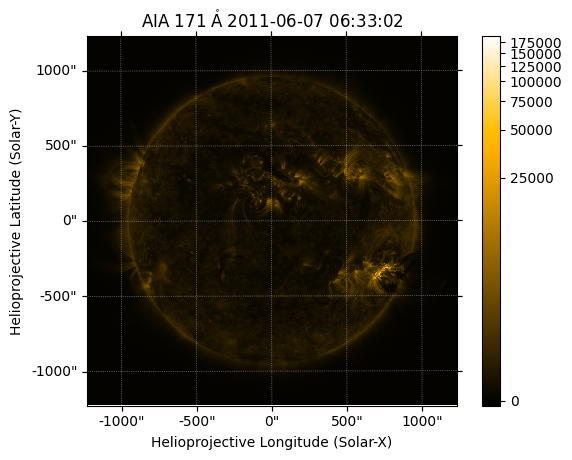

In [35]:
import matplotlib.pyplot as plt
fig=plt.figure()
ax=fig.add_subplot(projection=my_map)
my_map.plot(axes=ax)
plt.colorbar()

In [36]:
my_map.instrument

'AIA 3'

因为上图比较暗，可以使用 __<font color='#00FFFF'>clip_interval</font>__ 裁剪掉最暗的1%和最亮的0.5%

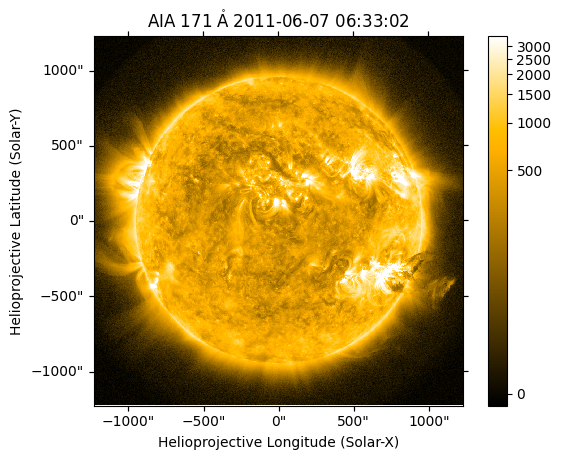

In [11]:
fig = plt.figure()
ax = fig.add_subplot(projection=my_map)

my_map.plot(axes=ax, clip_interval=(1, 99.5)*u.percent)
ax.grid(False)
plt.colorbar()

__<font color='#FF7F00'>5. Changing the Colormap and Normalization</font>__  

可以通过<font color='#00FFFF'>cmap</font>来更改不同的color map，[可选列表](https://docs.sunpy.org/en/stable/reference/visualization.html#module-sunpy.visualization.colormaps) 以及[matplotlib提供的](https://matplotlib.org/2.0.2/examples/color/colormaps_reference.html)

sdoaia171


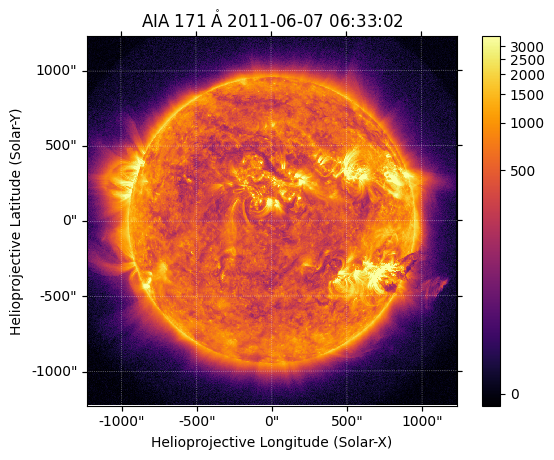

In [38]:
print(my_map.cmap.name)
fig = plt.figure()
ax = fig.add_subplot(projection=my_map)
my_map.plot(axes=ax, cmap='inferno', clip_interval=(1,99.5)*u.percent)
plt.colorbar()
plt.show()

画图时可以使用不同的标准化方式，上图的color bar也不是线性，可以更改默认，下图才采用 __对数归一化__  
<font color= '#00FFFF'>norm=matplotlb.colors.LogNorm()</font>   
[其他归一化列表](https://matplotlib.org/2.0.2/users/colormapnorms.html)

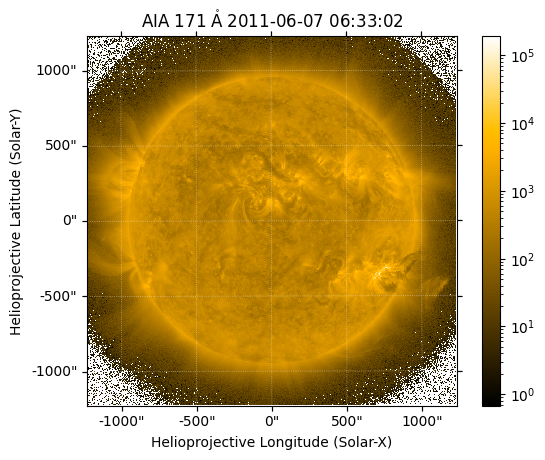

In [39]:
import matplotlib.colors

fig = plt.figure()
ax = fig.add_subplot(projection=my_map)
my_map.plot(norm=matplotlib.colors.LogNorm())
plt.colorbar()
plt.show()

__<font color='#FF7F00'>6. Overlaying Countours and Coordinates</font>__  
标注出特定值 For example, we can draw contours around the brightest 0.5% percent of pixels in the image:

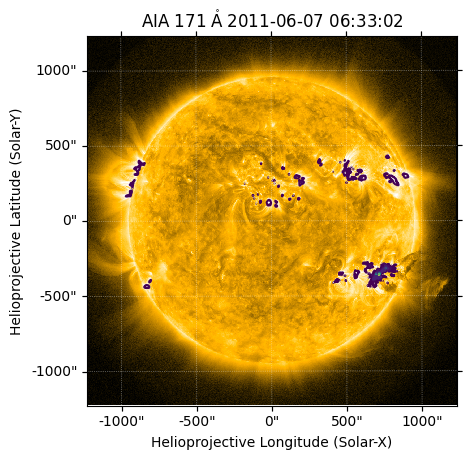

In [53]:
fig = plt.figure()
ax = fig.add_subplot(projection=my_map)
my_map.plot(axes=ax, clip_interval=(1,99.5)*u.percent)
my_map.draw_contours([2,5,10,50,90] * u.percent, axes=ax)
plt.show()

__画出边界__

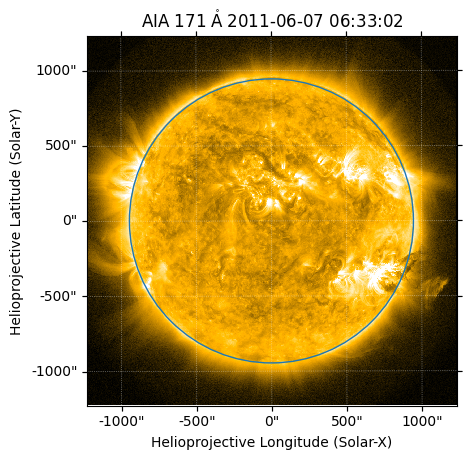

In [54]:
fig = plt.figure()
ax = fig.add_subplot(projection=my_map)
my_map.plot(axes=ax, clip_interval=(1,99.5)*u.percent)
my_map.draw_limb(axes=ax, color='C0')
plt.show()

__<font color='#FF7F00'>画出方框</font>__  
利用<font color='#00FFFF'>SkyCoord</font>可以创建出指定TxTy对应的world coordinate，之后用<font color='#00FFFF'>world_to_pixel</font>转化为矩阵中的位置，  
或者用pixel=(200,200)，有矩阵里的位置再用<font color='#00FFFF'>pixel_to_world</font>转化为world coordinate

c:\Users\19671\anaconda3\envs\sun\Lib\site-packages\astropy\visualization\wcsaxes\patches.py:196: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  super().__init__(vertices, **kwargs)


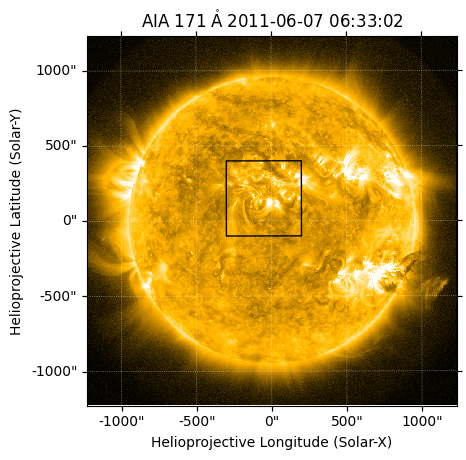

In [30]:
roi_bottom_left=SkyCoord(Tx=-300*u.arcsec,Ty=-100*u.arcsec,frame=my_map.coordinate_frame)
roi_top_right=SkyCoord(Tx=200*u.arcsec,Ty=400*u.arcsec,frame=my_map.coordinate_frame)
fig=plt.figure()
ax=fig.add_subplot(projection=my_map)
#qw=my_map.wcs.pixel_to_world(center_pixel[0], center_pixel[1]) 
my_map.plot(axes=ax,clip_interval=(1,99.5)*u.percent)
#my_map.draw_quadrangle(roi_bottom_left,top_right=qw,axes=ax,color='C0')
my_map.draw_quadrangle(roi_bottom_left,top_right=roi_top_right,axes=ax,color='black')

In [57]:
center_pixel=(511.5,511.5)
my_map.wcs.pixel_to_world(center_pixel[0], center_pixel[1])  

<SkyCoord (Helioprojective: obstime=2011-06-07T06:33:02.770, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.770, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406308, 0.04787238, 1.51846026e+11)>): (Tx, Ty) in arcsec
    (3.22309951, 1.38578135)>

In [60]:
my_map.wcs.world_to_pixel(roi_bottom_left)

(array(385.40636864), array(468.99931065))

__<font color='#FF7F00'>利用TxTy,进一步在指定位置上画上标记</font>__

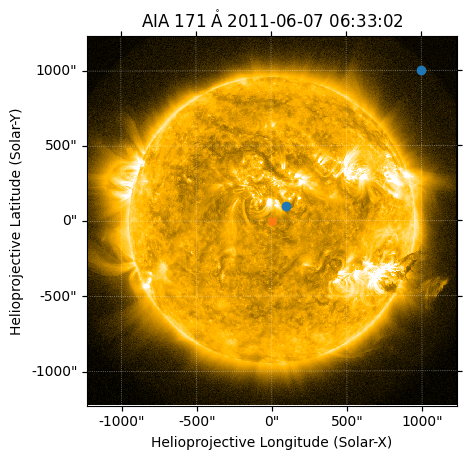

In [63]:
coords = SkyCoord(Tx=[100,1000] * u.arcsec, Ty=[100,1000] * u.arcsec, frame=my_map.coordinate_frame)

fig = plt.figure()
ax = fig.add_subplot(projection=my_map)
my_map.plot(axes=ax, clip_interval=(1,99.5)*u.percent)
ax.plot_coord(coords, 'o')
ax.plot_coord(my_map.center, 'X')
plt.show()

__<font color='#FF7F00'>7.Cropping Maps and Combining Pixels</font>__   
裁剪图像和拼合像素，利用<font color='#00FFFF'>submap，superpixel</font>  其他操作图片底层数据的方式见[Generic Map](https://docs.sunpy.org/en/stable/generated/api/sunpy.map.GenericMap.html#sunpy.map.GenericMap)

__裁剪图像__

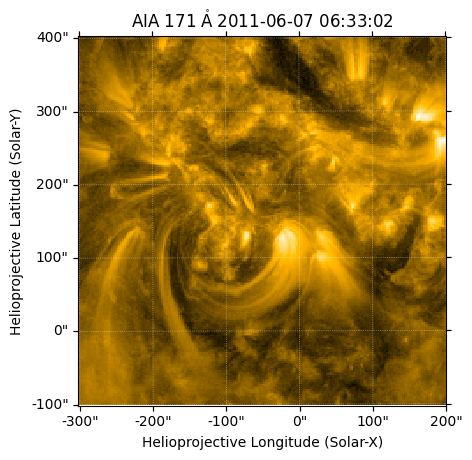

In [64]:
my_submap = my_map.submap(roi_bottom_left, top_right=roi_top_right)

fig = plt.figure()
ax = fig.add_subplot(projection=my_submap)
my_submap.plot(axes=ax)
plt.show()

__拼合像素__ 用于提升信噪比，利用<font color='#00FFFF'>superpixel</font>  在一个维度上结合四个像素点，即十六个像素为一个新的original pixel（这不是二十五个吗）

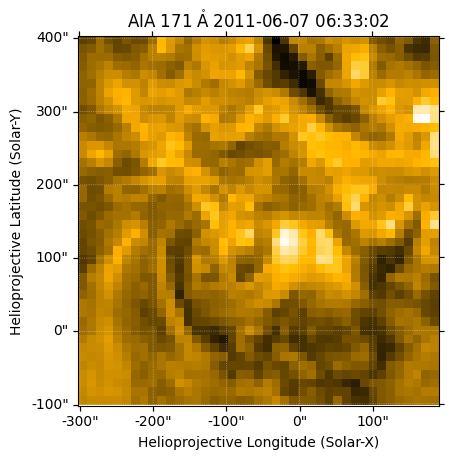

In [68]:
my_super_submap = my_submap.superpixel((5,5)*u.pixel)

fig = plt.figure()
ax = fig.add_subplot(projection=my_super_submap)
my_super_submap.plot(axes=ax)
plt.show()

In [71]:
print(len(my_super_submap.data))
print(len(my_submap.data))

42
210


__<font color='#FF7F00'>8.Map Sequence</font>__  
因为一个<font color='#00FFFF'>GenericMap</font>只能包括一个二维的信息，因此可以创建一个<font color='#00FFFF'>MapSequenc</font>来包括多张Map

In [72]:
another_map = sunpy.map.Map(sunpy.data.sample.EIT_195_IMAGE)  
map_seq = sunpy.map.Map([my_map, another_map], sequence=True)  

Files Downloaded:   0%|          | 0/1 [00:24<?, ?file/s]


1/0 files failed to download. Please check `.errors` for details


Files Downloaded: 100%|██████████| 1/1 [00:04<00:00,  4.70s/file]


可以向列表一样访问

Observatory,SDO
Instrument,AIA 3
Detector,AIA
Measurement,171.0 Angstrom
Wavelength,171.0 Angstrom
Observation Date,2011-06-07 06:33:02
Exposure Time,0.234256 s
Dimension,[1024. 1024.] pix
Coordinate System,helioprojective
Scale,[2.402792 2.402792] arcsec / pix
Reference Pixel,[511.5 511.5] pix

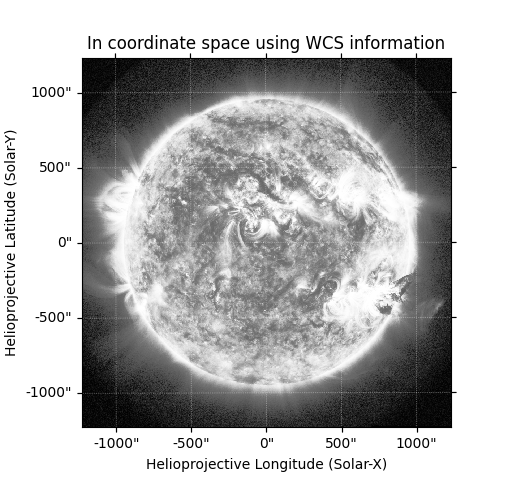
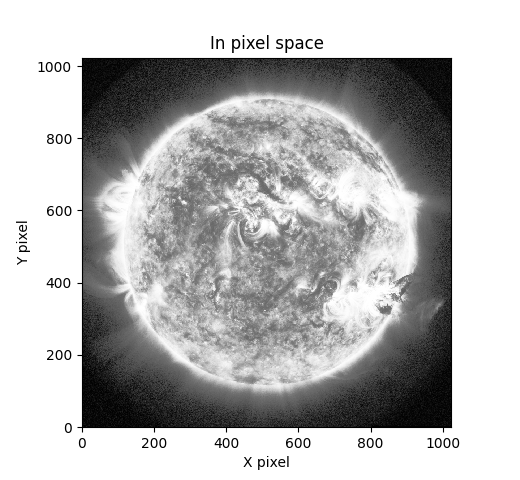
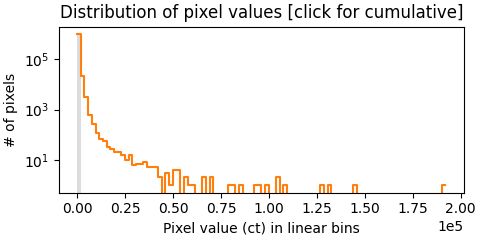
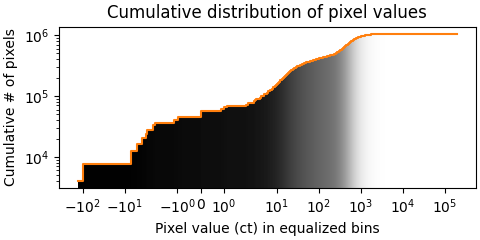

In [73]:
map_seq.maps[0]   

See https://docs.sunpy.org/en/stable/code_ref/map.html#fixing-map-metadata for how to fix metadata before loading it with sunpy.map.Map.
See https://fits.gsfc.nasa.gov/fits_standard.html forthe FITS unit standards. [sunpy.map.mapbase]


Observatory,SOHO
Instrument,EIT
Detector,EIT
Measurement,195.0 Angstrom
Wavelength,195.0 Angstrom
Observation Date,2011-06-07 20:37:52
Exposure Time,12.594 s
Dimension,[1024. 1024.] pix
Coordinate System,helioprojective
Scale,[2.63 2.63] arcsec / pix
Reference Pixel,[509.91 520.06] pix

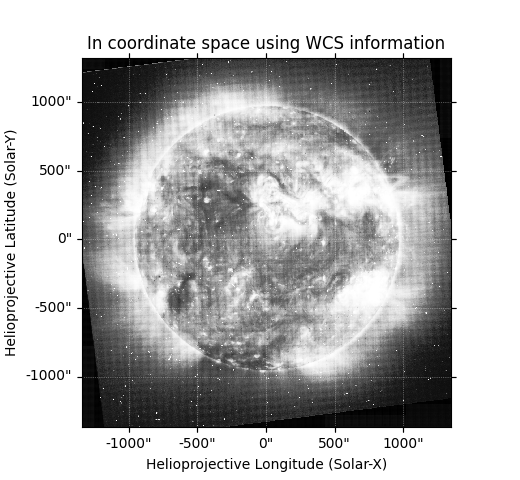
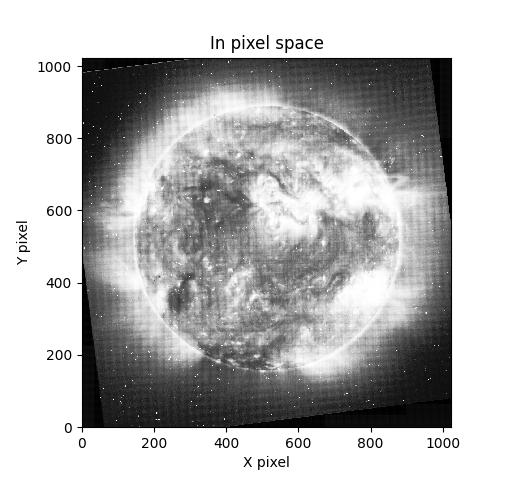
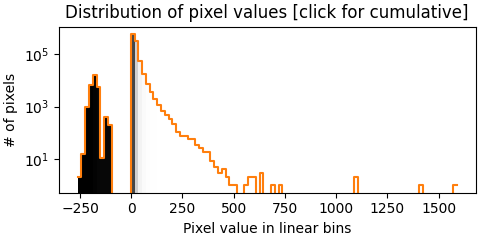
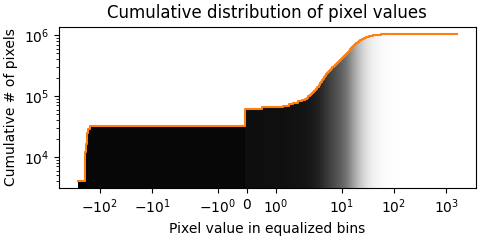

In [74]:
map_seq.maps[1]   

MapSequence可以包括不同形状的map，可以用<font color='#00FFFF'>all_maps_same_shape</font>检查是否一样的形状

In [75]:
map_seq.all_maps_same_shape()  

True

__<font color='#FF7F00'>将image data变成一个NumPy里的三维数组</font>__

In [76]:
map_seq_array = map_seq.as_array()  

In [77]:
map_seq_array.shape  

(1024, 1024, 2)

__<font size=5 color='#FF0000'>七. Timeseries</font>__  
<font color='#00FFFF'>TimeSersies</font> object 包括依赖时间的数据和对应的元数据，他们可以和多个一维数组使用，就像<font color='#00FFFF'>Map</font> object一样。重要的是，TimeSeries允许您选择特定的时间范围或以元数据感知的方式组合多个TimeSeries。

__<font color='#FF7F00'>1. Creating a TimeSeries</font>__

In [84]:
import sunpy.timeseries
import sunpy.data.sample  

sunpy.data.sample.GOES_XRS_TIMESERIES  
my_timeseries = sunpy.timeseries.TimeSeries(sunpy.data.sample.GOES_XRS_TIMESERIES)  

In [90]:
my_timeseries.quicklook

AttributeError: 'datetime.datetime' object has no attribute 'astype'